# Model_0

Essayer de creer un modele de base capable de generer les bounding box

In [15]:
import torch
import torchvision
import matplotlib.pyplot as plt

## Create the dataset

In [73]:
from torch.utils.data import Dataset

from pathlib import Path
from PIL import Image

class BoundingDataset(Dataset):
    """Is the dataset for the circle data"""
    def __init__(self,
                  image_path,
                    label_path,
                      transform: torchvision.transforms=None,
                      ignore: str=None):
        self.image_path = image_path
        self.label_path = label_path
        self.transform = transform
        self.ignore = ignore

        self.bounding_boxes: dict = {}
        self.images: dict = {}

        self.get_bounding_boxes(label_path)
        self.get_images(image_path)
    
    def get_bounding_boxes(self, label_path):
        for file_path in label_path.iterdir():
            with open(file_path, "r") as f:
                skip = False
                if self.ignore:
                    if self.ignore in file_path.stem:
                        skip = True
                if not skip:
                    data = f.readline()
                    data = data.split(" ")
                    self.bounding_boxes[file_path.stem] = {
                        "x": float(data[1]),
                        "y": float(data[2]),
                        "w": float(data[3]),
                        "h": float(data[4])}
    
    def get_images(self, image_path):
        for file_path in image_path.iterdir():
            skip = False
            if self.ignore:
                if self.ignore in file_path.stem:
                    skip = True
            if not skip:
                image = Image.open(file_path)
                if self.transform:
                    image_transformed = self.transform(image)
                    self.images[file_path.stem] = image_transformed
                else:
                    self.images[file_path.stem] = image

    def __getitem__(self, index):
        return (list(self.images.values())[index], list(self.bounding_boxes.values())[index])
    
    def __len__(self):
        return len(self.images)


In [74]:
from torchvision import transforms
train_transform = torchvision.transforms.Compose([  # Very simple transform for now
    transforms.ToTensor()
])

test_transform = torchvision.transforms.Compose([  # Very simple transform for now
    transforms.ToTensor()
])

train_dataset = BoundingDataset(image_path=Path("/Users/nicolasmarin/Documents/GitHub/drono-ai/data/red_circle_example/train/images"), 
                                label_path=Path("/Users/nicolasmarin/Documents/GitHub/drono-ai/data/red_circle_example/train/labels"),
                                transform=train_transform,
                                ignore="vid")

test_dataset = BoundingDataset(image_path=Path("/Users/nicolasmarin/Documents/GitHub/drono-ai/data/red_circle_example/test/images"), 
                               label_path=Path("/Users/nicolasmarin/Documents/GitHub/drono-ai/data/red_circle_example/test/labels"), 
                               transform=test_transform,
                               ignore="vid")


## Preview the data

501
466.0333333333333 252.75925925925924
34.66666666666674 40.237037037037


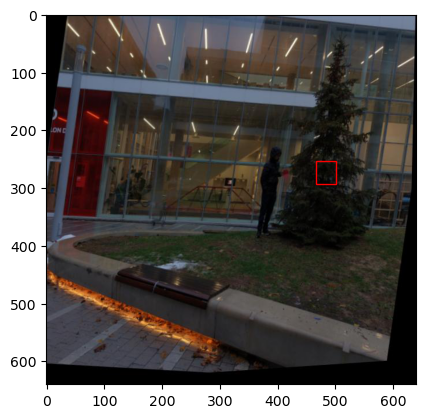

In [99]:
import random
import matplotlib.patches as patches

def preview_image(image, bounding_box=None):
    # Create figure and axes
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(image)

    # Create a Rectangle patch
    w, h = bounding_box[2] * image.shape[0], bounding_box[3] * image.shape[1]
    x, y = bounding_box[0] * image.shape[0], image.shape[1] - bounding_box[1] * image.shape[1]
    print(x, y)
    print(w, h)
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')

    # Add the patch to the Axes
    ax.add_patch(rect)

    plt.show()

print(len(train_dataset))
data = train_dataset[random.randrange(0, len(train_dataset))]
preview_image(data[0].permute(1, 2, 0), list(data[1].values()))

## Create the dataloaders

In [ ]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)

In [11]:
train_dataset[300][0].shape

torch.Size([3, 640, 640])

## Finetuning YOLOv11 nano

In [ ]:
from ultralytics import YOLO

/Users/nicolasmarin/anaconda3/envs/drono/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
model = YOLO("/Users/nicolasmarin/Documents/GitHub/drono-ai/notebooks/weights/weights.pt")

In [4]:
results = model("/Users/nicolasmarin/Documents/GitHub/drono-ai/notebooks/in/ai_images_22_03_2026/PXL_20260322_185243399.jpg")
results


image 1/1 /Users/nicolasmarin/Documents/GitHub/drono-ai/notebooks/in/ai_images_22_03_2026/PXL_20260322_185243399.jpg: 1280x960 1 red target, 586.0ms
Speed: 23.8ms preprocess, 586.0ms inference, 15.3ms postprocess per image at shape (1, 3, 1280, 960)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'black target', 1: 'blue target', 2: 'green target', 3: 'person', 4: 'red target', 5: 'white target', 6: 'yellow target'}
 obb: None
 orig_img: array([[[ 62, 100, 134],
         [ 66, 104, 138],
         [ 66, 104, 138],
         ...,
         [232, 208, 180],
         [233, 209, 181],
         [231, 207, 179]],
 
        [[ 59,  97, 131],
         [ 62, 100, 134],
         [ 63, 101, 135],
         ...,
         [231, 207, 179],
         [229, 205, 177],
         [227, 203, 175]],
 
        [[ 61,  99, 133],
         [ 61,  99, 133],
         [ 62, 100, 134],
         ...,
         [231, 207, 179],
         [232, 208, 180],
         [233, 209, 181]],
 
        ...,
 
        [[ 55,  56,  40],
         [ 66,  67,  51],
         [ 67,  68,  52],
         ...,
         [ 33,  51,  68],
         [ 28,  46,  63],
         [ 28,  48,  65]],


In [13]:
for result in results:
    print(result.boxes.xywhn)  # gets the xywh normalized


tensor([[0.5233, 0.3086, 0.1583, 0.1293]])


In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:

model.export(format="engine")

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.4.50 🚀 Python-3.11.13 torch-2.2.2 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: 0
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.
